Import package

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import linear_model
from sklearn.model_selection import train_test_split
import numpy as np
import seaborn as sb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


Load Data





In [31]:
!wget https://raw.githubusercontent.com/BurungMother/GSLC-AI-ML/main/ml.csv

--2021-12-13 13:53:25--  https://raw.githubusercontent.com/BurungMother/GSLC-AI-ML/main/ml.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 61194 (60K) [text/plain]
Saving to: ‘ml.csv’

ml.csv              100%[===================>]  59.76K  --.-KB/s    in 0.01s   

2021-12-13 13:53:25 (4.39 MB/s) - ‘ml.csv’ saved [61194/61194]



In [33]:
tn = pd.read_csv('ml.csv')
print(tn.dtypes)
print(tn.isna().values.any())

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object
True


In [34]:
print(tn.info())
print(tn.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
       PassengerId    Survived      Pclass  ...       SibSp       Parch        Fare
count   891.000000  891.000000  891.000000  ...  891.000000  891.000000  891.000000
mean    446.000000    0.383838    2.308642  ...    0.523008    0.381594

Remove NaN data

In [36]:
np.random.seed(42)

ages = np.array((tn['Age'].value_counts() / tn.shape[0]).index.tolist())
age_weights = (tn['Age'].value_counts() / tn['Age'].notna().sum()).values

fill_vals = np.random.choice(ages, tn['Age'].isna().sum(), p=age_weights)
fill_df = pd.DataFrame(index =tn.index[tn.Age.isna()], data= fill_vals,columns=['Val'])
ser = pd.Series(fill_df['Val'].values, index=fill_df.index)

tn['Age'] = tn['Age'].fillna(ser)

Select particular column and Visualise data

   PassengerId  Pclass   Age  SibSp  Parch     Fare  Survived
0            1       3  22.0      1      0   7.2500         0
1            2       1  38.0      1      0  71.2833         1
2            3       3  26.0      0      0   7.9250         1
3            4       1  35.0      1      0  53.1000         1
4            5       3  35.0      0      0   8.0500         0


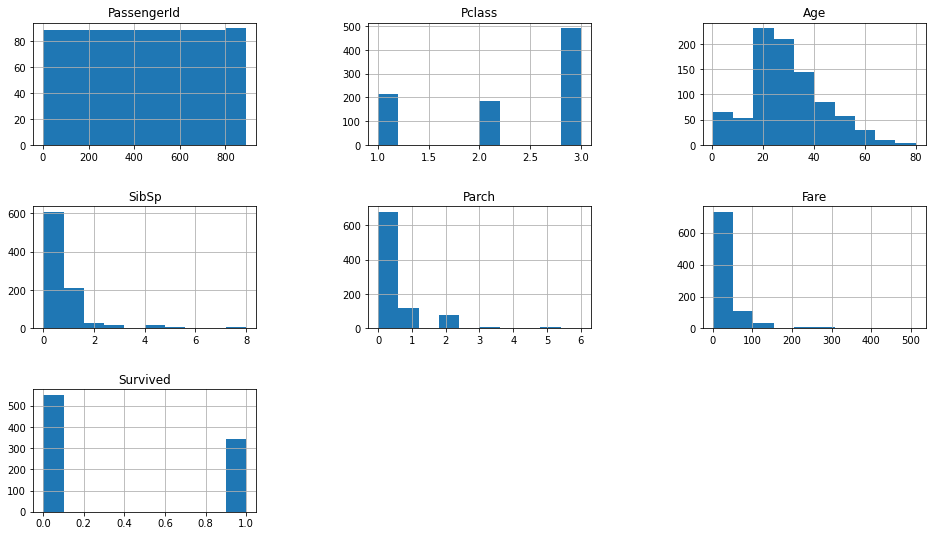

In [38]:
newtn = tn[['PassengerId','Pclass','Age','SibSp','Parch','Fare','Survived']]
print(newtn.head())
newtn.hist()
plt.subplots_adjust(hspace = 0.5, wspace = 0.5)
plt.rcParams["figure.figsize"] = [16,9]
plt.show()

Visualise data (Scatter)

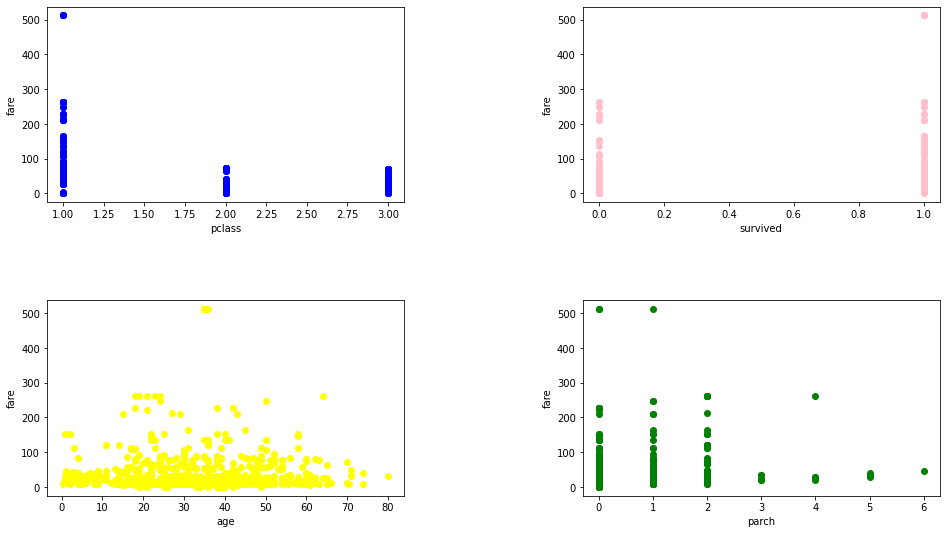

In [43]:
plt.subplot(221)
plt.scatter(newtn["Pclass"], newtn["Fare"], color="blue")
plt.xlabel("pclass")
plt.ylabel("fare")

plt.subplot(222)
plt.scatter(newtn["Survived"], newtn["Fare"], color="pink")
plt.xlabel("survived")
plt.ylabel("fare")

plt.subplot(223)
plt.scatter(newtn["Age"], newtn["Fare"], color="yellow")
plt.xlabel("age")
plt.ylabel("fare")

plt.subplot(224)
plt.scatter(newtn["Parch"], newtn["Fare"], color="green")
plt.xlabel("parch")
plt.ylabel("fare")

plt.subplots_adjust(hspace = 0.5, wspace = 0.5)
plt.rcParams["figure.figsize"] = [16,9]
plt.show()

Regression - Survived

In [44]:
train, test = train_test_split(newtn, test_size=0.2)
regression = linear_model.LinearRegression()
regression.fit(train[["Survived"]], train[["Fare"]])
print('Coefficients: ', regression.coef_)
print('Intercept: ',regression.intercept_)

Coefficients:  [[23.06557915]]
Intercept:  [23.14875147]


Visualise the regression to the plot

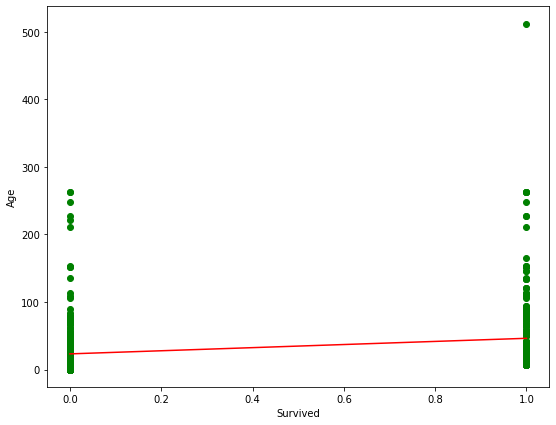

In [46]:
plt.scatter(train["Survived"], train["Fare"],  color='green')
plt.plot(train[["Survived"]], regression.coef_ * train[["Survived"]] + regression.intercept_, '-r')
plt.xlabel("Survived")
plt.ylabel("Age")
plt.rcParams["figure.figsize"] = [9,7]
plt.show()

Visualisation (Seaborn)

/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


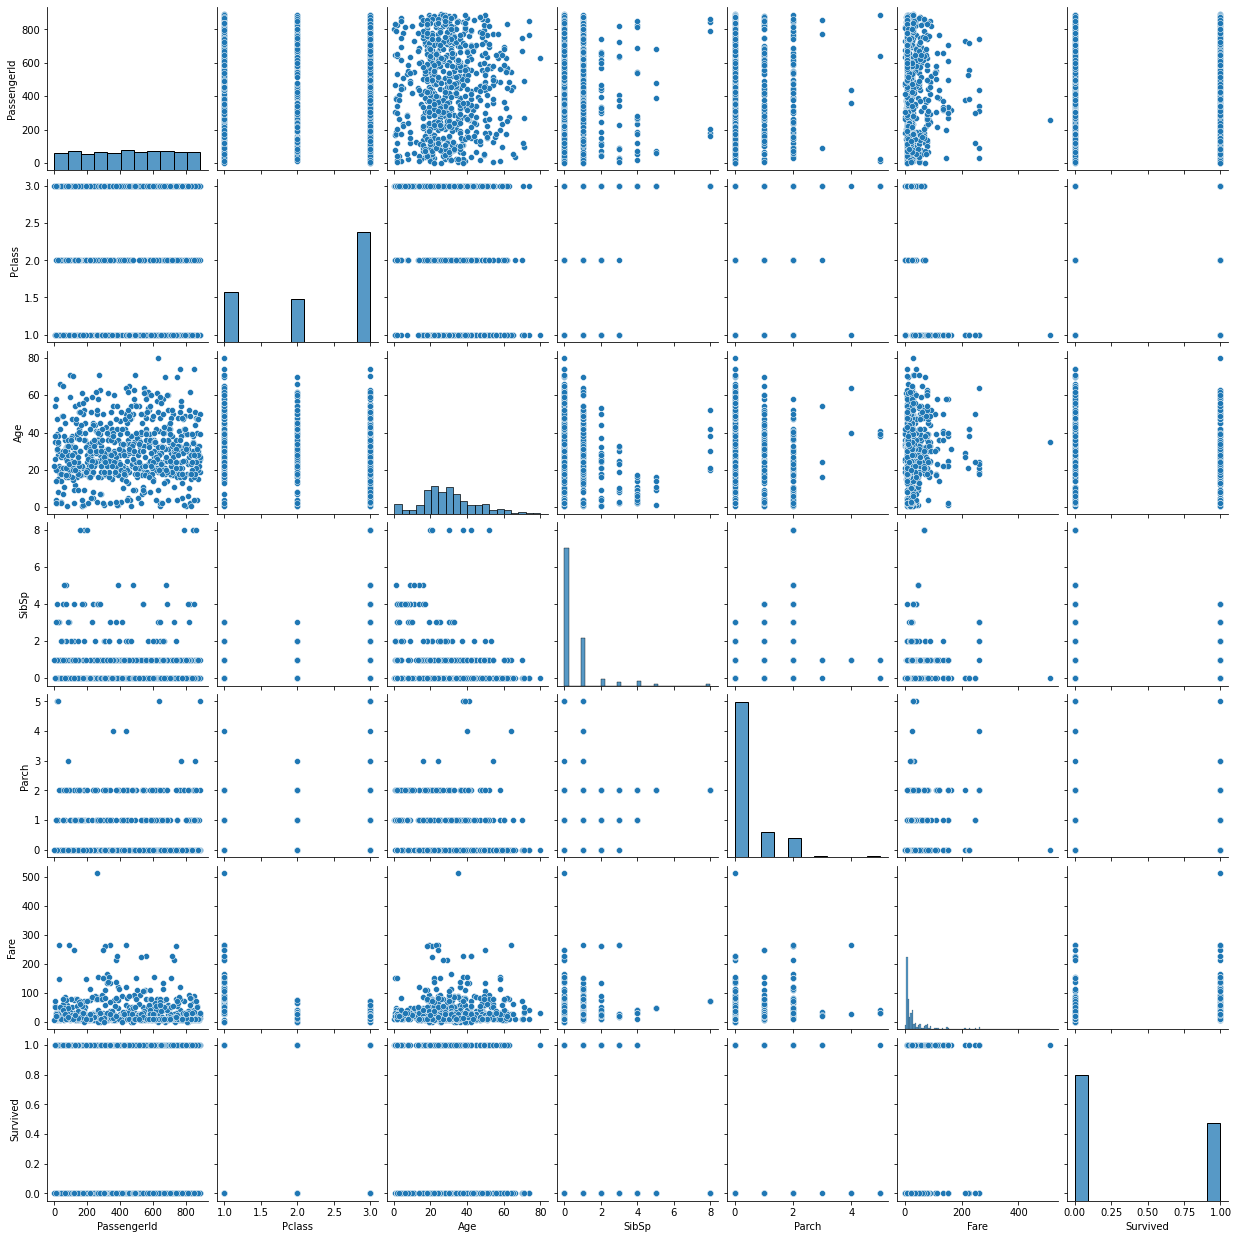

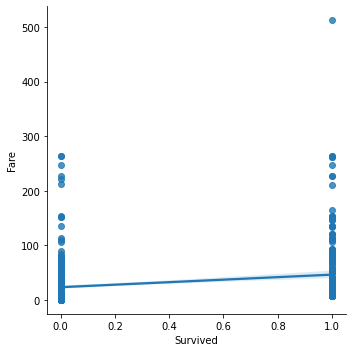

In [47]:
sb.pairplot(train)
sb.lmplot("Survived", "Fare", data = train)
plt.show()

Predict new data & evaluate model

In [51]:
prediction = regression.predict(test[["Survived"]])
for i in range(len(test)):
  print(test[["Survived"]].values[i], prediction[i])

print("MAE : ", mean_absolute_error(test[["Fare"]], prediction))
print("MSE : ", mean_squared_error(test[["Fare"]], prediction))
print("R2 : ", r2_score(test[["Fare"]], prediction))

[0] [23.14875147]
[1] [46.21433063]
[1] [46.21433063]
[0] [23.14875147]
[1] [46.21433063]
[0] [23.14875147]
[0] [23.14875147]
[0] [23.14875147]
[1] [46.21433063]
[1] [46.21433063]
[1] [46.21433063]
[0] [23.14875147]
[0] [23.14875147]
[0] [23.14875147]
[1] [46.21433063]
[0] [23.14875147]
[1] [46.21433063]
[1] [46.21433063]
[1] [46.21433063]
[1] [46.21433063]
[1] [46.21433063]
[0] [23.14875147]
[0] [23.14875147]
[1] [46.21433063]
[0] [23.14875147]
[0] [23.14875147]
[1] [46.21433063]
[0] [23.14875147]
[0] [23.14875147]
[1] [46.21433063]
[1] [46.21433063]
[0] [23.14875147]
[0] [23.14875147]
[0] [23.14875147]
[0] [23.14875147]
[0] [23.14875147]
[0] [23.14875147]
[1] [46.21433063]
[0] [23.14875147]
[1] [46.21433063]
[0] [23.14875147]
[1] [46.21433063]
[0] [23.14875147]
[0] [23.14875147]
[1] [46.21433063]
[0] [23.14875147]
[1] [46.21433063]
[0] [23.14875147]
[0] [23.14875147]
[1] [46.21433063]
[0] [23.14875147]
[0] [23.14875147]
[0] [23.14875147]
[1] [46.21433063]
[0] [23.14875147]
[0] [23.14